# Notebook 02: Rigorous Predictive Modeling of Wage Determinants

**EquiPay Canada — Research-Grade Machine Learning Analysis**

---

## Overview

This notebook develops and evaluates predictive models for hourly wages using the Labour Force Survey (LFS) PUMF data (2010-2025). We implement a **rigorous model development pipeline** following best practices in applied machine learning for causal inference.

### Research Questions
1. How accurately can wages be predicted from observable characteristics?
2. What is the magnitude of the gender wage gap after controlling for human capital?
3. Which model provides the best predictive performance with proper uncertainty quantification?

## Methodological Framework

### Model Development Pipeline

| Stage | Method | Purpose |
|-------|--------|---------|
| **Feature Engineering** | VIF Analysis, Correlation Screening | Multicollinearity diagnosis |
| **Model Selection** | Nested Cross-Validation | Unbiased performance estimation |
| **Hyperparameter Tuning** | Grid/Random Search with CV | Optimize model complexity |
| **Model Diagnostics** | Residual Analysis, Calibration | Validate assumptions |
| **Uncertainty Quantification** | Bootstrap CIs, Prediction Intervals | Honest error bars |
| **Interpretability** | SHAP Values, Permutation Importance | Feature attribution |

### Model Comparison Framework

| Model | Type | Strengths | Assumptions |
|-------|------|-----------|-------------|
| **OLS** | Parametric | Interpretable coefficients | Linearity, normality, homoscedasticity |
| **Ridge/Lasso** | Regularized | Prevents overfitting | Same as OLS |
| **Random Forest** | Ensemble | Captures non-linearity | None (non-parametric) |
| **XGBoost** | Gradient Boosting | SOTA performance | None (non-parametric) |

### Nested Cross-Validation

**Why nested CV?** (Cawley & Talbot, 2010)
- **Inner loop**: Hyperparameter tuning
- **Outer loop**: Unbiased performance estimation
- Prevents information leakage and optimistic bias

```
Outer Fold 1: [Test] | [Inner CV for tuning ────────────]
Outer Fold 2: ─────── [Test] | [Inner CV ─────────────────]
Outer Fold 3: ──────────────── [Test] | [Inner CV ────────]
...
```

### Key Econometric Considerations
- **Log-linear specification**: $\ln(W_i) = X\beta + \gamma \cdot \text{Female}_i + \epsilon_i$ (Mincer, 1974)
- **Robust inference**: HC3 standard errors for heteroskedasticity (MacKinnon & White, 1985)
- **Effect sizes**: Report with confidence intervals (APA 7th Edition)

## Data Source
- **Labour Force Survey PUMF** (Statistics Canada Catalogue 71M0001X)
- **Period**: 2010-2025 (16 years, N ≈ 100,000+ observations)
- **Sample**: Working-age population with valid hourly wages

---

In [1]:
# ============================================================================
# SETUP: Import Libraries and Configure Environment
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Statistical tests
from scipy import stats as sp_stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add project root
sys.path.insert(0, str(Path.cwd().parent))

# Force reload of custom modules to pick up changes
import importlib
import src.leakage_prevention
importlib.reload(src.leakage_prevention)

from src.constants import COLS, normalize_column_names, DATA_SCOPE_START, DATA_SCOPE_END

# NEW: Weighted ML utilities for survey data
from src.ml_utils import WeightedMLSplitter, WeightedMetrics, WeightedGapAnalysis

# =============================================================================
# CRITICAL: LEAKAGE PREVENTION - Import first for maximum protection
# =============================================================================
from src.leakage_prevention import (
    LeakageGuard, 
    LeakageConfig,
    TARGET_DERIVED_FEATURES,
    check_r2_sanity,
    is_wage_derived
)

# Initialize leakage guard with custom config
leakage_config = LeakageConfig(
    correlation_threshold=0.90,
    max_realistic_r2=0.60,
    warning_correlation_threshold=0.70,
    strict_mode=True,
    verbose=True
)
LEAKAGE_GUARD = LeakageGuard(config=leakage_config)

print("=" * 70)
print("🛡️  DATA LEAKAGE PREVENTION ACTIVE")
print("=" * 70)
print(f"✓ {len(TARGET_DERIVED_FEATURES)} wage-derived features BLOCKED")
print(f"✓ Target correlation threshold: {leakage_config.correlation_threshold}")
print(f"✓ R² sanity check threshold: {leakage_config.max_realistic_r2}")
print(f"✓ Pattern matching for 'wage', 'earn', 'income' terms: ENABLED")
print("=" * 70)

# Publication-quality figures
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white'
})
plt.style.use('seaborn-v0_8-whitegrid')

# Ensure figures directory exists
Path('../reports/figures').mkdir(parents=True, exist_ok=True)

print("\n✓ Libraries loaded successfully")
print("✓ Weighted ML utilities loaded (WeightedMLSplitter, WeightedMetrics)")
print(f"✓ Analysis period: {DATA_SCOPE_START}-{DATA_SCOPE_END}")

INFO:src.leakage_prevention:LeakageGuard initialized for target: REAL_HRLYEARN
INFO:src.leakage_prevention:  Blocked features: 32
INFO:src.leakage_prevention:  Safe features: 65
INFO:src.leakage_prevention:LeakageGuard initialized for target: REAL_HRLYEARN
INFO:src.leakage_prevention:  Blocked features: 32
INFO:src.leakage_prevention:  Safe features: 65
INFO:src.leakage_prevention:LeakageGuard initialized for target: REAL_HRLYEARN
INFO:src.leakage_prevention:  Blocked features: 32
INFO:src.leakage_prevention:  Safe features: 65


🛡️  DATA LEAKAGE PREVENTION ACTIVE
✓ 32 wage-derived features BLOCKED
✓ Target correlation threshold: 0.9
✓ R² sanity check threshold: 0.6
✓ Pattern matching for 'wage', 'earn', 'income' terms: ENABLED

✓ Libraries loaded successfully
✓ Weighted ML utilities loaded (WeightedMLSplitter, WeightedMetrics)
✓ Analysis period: 2010-2025


## 1. Data Loading & Preprocessing

Load the processed LFS data prepared in Notebook 01. We apply:
- Column normalization
- Creation of derived features
- Target variable transformation

In [2]:
# ============================================================================
# DATA LOADING VIA EquiPayDataStore (DuckDB + Parquet)
# ============================================================================
# Memory-efficient: queries 19.5M rows using ~300MB RAM
# Uses Parquet files directly - no need to generate CSV first

from src.data_store import EquiPayDataStore
from pathlib import Path

print("🚀 Loading data via EquiPayDataStore")
print("=" * 60)

# Initialize data store
PROJECT_ROOT = Path.cwd().parent
store = EquiPayDataStore(
    parquet_path=str(PROJECT_ROOT / "data" / "parquet"),
    raw_csv_path=str(PROJECT_ROOT / "data" / "raw" / "lfs")
)

# Get summary stats
# Get summary stats using new API
total_records = store.count()
years = store.years()
print(f"✓ Data source: {'Parquet + DuckDB'}")
print(f"✓ Total records: {total_records:,}")
print(f"✓ Valid wage records: {total_records:,}")
print(f"✓ Year range: {min(years)} - {max(years)}")

# Load full dataset for ML (with valid wages only)
df = store.query().where('HRLYEARN > 0').to_pandas()
df = normalize_column_names(df)

print(f"\n✓ Loaded {len(df):,} records for modeling")

🚀 Loading data via EquiPayDataStore


INFO:src.data_store:DuckDB: Registered Parquet source: /mnt/c/Users/Administrator/equipay-canada/data/parquet


✓ Data source: parquet
✓ Total records: 19,552,818
✓ Valid wage records: 9,877,977
✓ Year range: 2010 - 2025


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


✓ Loaded 9,877,977 records for modeling


In [3]:
# Identify columns
gender_col = COLS.GENDER if COLS.GENDER in df.columns else 'SEX'
weight_col = 'FINALWT'  # MANDATORY: Survey weights for population inference

# Validate weight column exists
if weight_col not in df.columns:
    raise ValueError(f"Weight column '{weight_col}' not found! Survey weights are MANDATORY.")

# Use REAL hourly earnings for cross-year model training (inflation-adjusted)
# This ensures predictions are in 2010 constant dollars
if COLS.REAL_HOURLY_EARNINGS in df.columns:
    wage_col = COLS.REAL_HOURLY_EARNINGS
    print("✓ Using REAL hourly earnings (inflation-adjusted to 2010$)")
elif 'REAL_HRLYEARN' in df.columns:
    wage_col = 'REAL_HRLYEARN'
    print("✓ Using REAL hourly earnings (inflation-adjusted to 2010$)")
else:
    wage_col = COLS.HOURLY_EARNINGS if COLS.HOURLY_EARNINGS in df.columns else 'HRLYEARN'
    print("⚠ Real wages not available - using nominal wages")

print(f"Gender column: {gender_col}")
print(f"Wage column: {wage_col}")
print(f"Weight column: {weight_col} ✓ (MANDATORY for population inference)")

# Create IS_FEMALE (Female code = 2)
df['IS_FEMALE'] = (df[gender_col] == 2).astype(int)

# Show weight statistics
print(f"\nSurvey weight statistics:")
print(f"  Total weighted population: {df[weight_col].sum():,.0f}")
print(f"  Mean weight: {df[weight_col].mean():.1f}")
print(f"  Weight range: [{df[weight_col].min():.1f}, {df[weight_col].max():.1f}]")

✓ Using REAL hourly earnings (inflation-adjusted to 2010$)
Gender column: GENDER
Wage column: REAL_HRLYEARN
Weight column: FINALWT ✓ (MANDATORY for population inference)

Survey weight statistics:
  Total weighted population: 3,021,764,352
  Mean weight: 305.9
  Weight range: [1.0, 6526.0]


## 2. Feature Engineering & Multicollinearity Assessment

**Critical diagnostic step:** We assess multicollinearity using the Variance Inflation Factor (VIF). 

**VIF Interpretation:**
- VIF = 1: No correlation with other predictors
- VIF < 5: Acceptable
- VIF > 10: Severe multicollinearity (requires remediation)

In [ ]:
# =============================================================================
# DEFINE COMPREHENSIVE FEATURE SET (Using all 60 LFS columns)
# =============================================================================
# Organized by theory-driven categories for pay equity analysis

potential_features = [
    # Demographics & Identity (for gap decomposition)
    'IS_FEMALE',           # Primary variable of interest
    COLS.AGE_12,           # Age group (experience proxy)
    'MARSTAT',             # Marital status
    'IMMIG',               # Immigration status (key equity dimension)
    
    # Human Capital
    COLS.EDUC,             # Education level
    COLS.TENURE,           # Job tenure (years with employer)
    'PREVTEN',             # Previous job tenure
    'EXPERIENCE',          # Derived: Age - Education - 6
    'EXPERIENCE_SQ',       # Derived: Experience squared
    'SCHOOLN',             # Currently attending school
    
    # Job Characteristics
    COLS.NOC_10,           # Occupation (10 categories)
    'NOC_43',              # Occupation (43 detailed categories)
    COLS.NAICS_21,         # Industry sector
    'COWMAIN',             # Class of worker (public/private/self-emp)
    COLS.FTPTMAIN,         # Full-time/part-time status
    COLS.UNION,            # Union membership
    'PERMTEMP',            # Permanent vs temporary
    'ESTSIZE',             # Establishment size
    'FIRMSIZE',            # Firm size
    'MJH',                 # Multiple job holder
    
    # Work Hours
    'UHRSMAIN',            # Usual hours worked (main job)
    'AHRSMAIN',            # Actual hours worked (main job)
    
    # Geography
    COLS.PROV,             # Province
    'CMA',                 # Census Metropolitan Area
    
    # Family Responsibilities (motherhood penalty)
    'EFAMTYPE',            # Economic family type
    'AGYOWNK',             # Age of youngest child
    
    # Reason for Part-Time (occupational choice)
    'WHYPT',               # Reason for part-time work
]

# Filter to available features (must exist in dataset)
features = [f for f in potential_features if f in df.columns]
print(f"Total potential features: {len(potential_features)}")
print(f"Available in dataset: {len(features)}")

# Filter out features with >50% missing values to avoid losing most data
null_rates = df[features].isna().mean()
high_null_features = null_rates[null_rates > 0.50].index.tolist()
if high_null_features:
    print(f"\n⚠ Excluding {len(high_null_features)} features with >50% missing:")
    for f in high_null_features:
        print(f"   - {f}: {null_rates[f]*100:.1f}% missing")
    features = [f for f in features if f not in high_null_features]

print(f"\nFeatures for modeling: {len(features)}")

# Target
target = wage_col

# Remove rows with missing target or key features
df_model = df[features + [target]].dropna()
print(f"\nRows for modeling: {len(df_model):,}")

Available features: ['IS_FEMALE', 'EDUC', 'NOC_10', 'PROV', 'AGE_12', 'TENURE', 'FTPTMAIN', 'UNION']

Rows for modeling: 9,877,977


In [5]:
# Prepare X and y
X = df_model[features]
y = df_model[target]

# Log transform target for better distribution
y_log = np.log(y.clip(lower=1))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget statistics:")
print(f"  Original - Mean: ${y.mean():.2f}, Std: ${y.std():.2f}")
print(f"  Log - Mean: {y_log.mean():.3f}, Std: {y_log.std():.3f}")

X shape: (9877977, 8)
y shape: (9877977,)

Target statistics:
  Original - Mean: $23.67, Std: $12.88
  Log - Mean: 3.040, Std: 0.488


In [6]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

Training set: 7,902,381 samples
Test set: 1,975,596 samples


In [7]:
# Variance Inflation Factor (VIF) Analysis
print("=" * 60)
print("MULTICOLLINEARITY DIAGNOSTICS: VARIANCE INFLATION FACTOR")
print("=" * 60)

# Calculate VIF for each feature
X_vif = X.dropna()
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False)

print(f"\n{'Feature':<20} {'VIF':>10} {'Status':>15}")
print("-" * 50)
for _, row in vif_data.iterrows():
    if row['VIF'] > 10:
        status = "⚠️ SEVERE"
    elif row['VIF'] > 5:
        status = "⚠ MODERATE"
    else:
        status = "✓ OK"
    print(f"{row['Feature']:<20} {row['VIF']:>10.2f} {status:>15}")

# Summary
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n⚠️ WARNING: {len(high_vif)} feature(s) with VIF > 10")
    print("   Consider removing or combining these features.")
else:
    print("\n✓ No severe multicollinearity detected (all VIF < 10)")

MULTICOLLINEARITY DIAGNOSTICS: VARIANCE INFLATION FACTOR

Feature                     VIF          Status
--------------------------------------------------
FTPTMAIN                   9.15      ⚠ MODERATE
AGE_12                     6.83      ⚠ MODERATE
UNION                      6.51      ⚠ MODERATE
PROV                       6.16      ⚠ MODERATE
EDUC                       5.53      ⚠ MODERATE
NOC_10                     4.98            ✓ OK
TENURE                     3.01            ✓ OK
IS_FEMALE                  2.20            ✓ OK

✓ No severe multicollinearity detected (all VIF < 10)


## 2b. Theory-Driven Econometric Feature Engineering

**NEW: Enhanced Features Based on Labor Economics Theory**

This section implements the `EconometricFeatureEngineer` to create features grounded in econometric theory:

| Category | Features | Theory Source |
|----------|----------|---------------|
| **Distributional** | RIF, quantile position | Firpo, Fortin & Lemieux (2009) |
| **Segregation** | Duncan index, occupation typicality | Duncan & Duncan (1955) |
| **Propensity** | Propensity scores, IPW weights | Rosenbaum & Rubin (1983) |
| **Counterfactual** | Oaxaca-Blinder derived | Oaxaca (1973), Blinder (1973) |
| **Glass Ceiling** | Upper-tail penalty indicators | Albrecht et al. (2003) |
| **Selection** | Mills ratio approximation | Heckman (1979) |

### Anti-Overfitting Safeguards
- **VIF Filtering**: Remove features with VIF > 10
- **Variance Threshold**: Remove near-constant features (var < 0.01)
- **Correlation Screening**: Remove highly correlated pairs (|r| > 0.95)
- **Target Correlation**: Require minimum predictive signal (|r| > 0.01)

In [8]:
# ============================================================================
# ECONOMETRIC FEATURE ENGINEERING
# ============================================================================
# Import the theory-driven feature engineering module

from src.econometric_features import (
    EconometricFeatureEngineer, 
    FeatureConfig, 
    FeatureComplexity
)

print("=" * 70)
print("THEORY-DRIVEN ECONOMETRIC FEATURE ENGINEERING")
print("=" * 70)

# Configure feature engineering with anti-overfitting safeguards
config = FeatureConfig(
    complexity=FeatureComplexity.STANDARD,  # Balanced: ~49 features
    max_vif=10.0,                           # Remove features with VIF > 10
    min_variance=0.01,                      # Remove near-constant features
    max_pairwise_correlation=0.95,          # Remove highly correlated pairs
    min_correlation_with_target=0.01,       # Require predictive signal
    scale_features=True,
    compute_selection_features=True,
    compute_temporal_features=False,        # Disable for cross-sectional
    random_state=42
)

print(f"\nComplexity Level: {config.complexity.name}")
print(f"Anti-Overfitting Thresholds:")
print(f"  Max VIF: {config.max_vif}")
print(f"  Min Variance: {config.min_variance}")
print(f"  Max Pairwise Correlation: {config.max_pairwise_correlation}")
print(f"  Min Target Correlation: {config.min_correlation_with_target}")

THEORY-DRIVEN ECONOMETRIC FEATURE ENGINEERING

Complexity Level: STANDARD
Anti-Overfitting Thresholds:
  Max VIF: 10.0
  Min Variance: 0.01
  Max Pairwise Correlation: 0.95
  Min Target Correlation: 0.01


In [9]:
# Create the feature engineer
# We use a sample for fitting to avoid memory issues with large datasets

# Prepare sample for feature engineering
n_sample = min(50_000, len(df_model))
df_sample = df_model.sample(n=n_sample, random_state=42).copy()

# Ensure required columns exist
df_sample['IS_FEMALE'] = (df_sample['IS_FEMALE'] if 'IS_FEMALE' in df_sample.columns 
                          else (df_sample[gender_col] == 2).astype(int))
df_sample['LOG_WAGE'] = y_log.loc[df_sample.index]

print(f"Using {n_sample:,} records for feature engineering")
print(f"Female ratio: {df_sample['IS_FEMALE'].mean():.1%}")

# Initialize engineer
engineer = EconometricFeatureEngineer(
    config=config,
    gender_col='IS_FEMALE',
    wage_col='LOG_WAGE',
    female_code=1  # IS_FEMALE uses 1 for female
)

# Fit and transform
print("\nFitting econometric feature engineer...")
df_enhanced = engineer.fit_transform(df_sample)

# Show created features by category
print(f"\n✓ Created {len(engineer.feature_metadata_)} theory-driven features")
print("\nFeatures by Category:")
print("-" * 50)
categories = {}
for name, meta in engineer.feature_metadata_.items():
    cat = meta.category
    if cat not in categories:
        categories[cat] = []
    categories[cat].append(name)

for cat, feats in sorted(categories.items()):
    print(f"  {cat}: {len(feats)} features")

INFO:src.econometric_features:Fitting EconometricFeatureEngineer...


Using 50,000 records for feature engineering
Female ratio: 49.6%

Fitting econometric feature engineer...


INFO:src.econometric_features:Feature engineer fitted successfully



✓ Created 22 theory-driven features

Features by Category:
--------------------------------------------------
  counterfactual: 7 features
  distributional: 5 features
  glass_ceiling: 3 features
  propensity: 4 features
  segregation: 3 features


In [10]:
# Apply automatic feature selection with anti-overfitting safeguards
print("=" * 70)
print("AUTOMATIC FEATURE SELECTION + LEAKAGE PREVENTION")
print("=" * 70)

# Get target variable
y_sample = df_enhanced['LOG_WAGE']

# =============================================================================
# STEP 1: Run econometric feature selection
# =============================================================================
selected_features = engineer.select_features(df_enhanced, y_sample)
print(f"\n✓ Initial selection: {len(selected_features)} features")

# =============================================================================
# STEP 2: CRITICAL - Validate through LeakageGuard
# =============================================================================
print("\n🛡️  LEAKAGE GUARD VALIDATION")
print("-" * 50)

# Check each selected feature for leakage potential
safe_features = []
blocked_features = []

for feat in selected_features:
    if is_wage_derived(feat):
        blocked_features.append(feat)
    else:
        safe_features.append(feat)

# Also run correlation-based detection
if len(df_enhanced) > 0:
    X_selected = df_enhanced[safe_features].copy() if safe_features else pd.DataFrame()
    validation = LEAKAGE_GUARD.validate_features(X_selected, y_sample)
    
    # Remove any correlation-flagged features
    if validation['flagged_features']:
        for feat_info in validation['flagged_features']:
            feat_name = feat_info['feature'] if isinstance(feat_info, dict) else str(feat_info)
            if feat_name in safe_features:
                safe_features.remove(feat_name)
                blocked_features.append(f"{feat_name} (correlation)")

# Report
if blocked_features:
    print(f"⛔ BLOCKED {len(blocked_features)} wage-derived features:")
    for feat in blocked_features[:10]:
        print(f"   - {feat}")
    if len(blocked_features) > 10:
        print(f"   ... and {len(blocked_features) - 10} more")
else:
    print("✓ No wage-derived features detected")

print(f"\n✓ FINAL SAFE FEATURES: {len(safe_features)}")
selected_features = safe_features

# =============================================================================
# STEP 3: Show removal reasons summary
# =============================================================================
print(f"  Removed {len(engineer.feature_metadata_) - len(selected_features)} total features")

if engineer.removed_features_:
    print("\nRemoval Reasons Summary:")
    reasons = {}
    for feat, reason in engineer.removed_features_.items():
        if reason not in reasons:
            reasons[reason] = 0
        reasons[reason] += 1
    for reason, count in sorted(reasons.items(), key=lambda x: -x[1]):
        print(f"  {reason}: {count} features")

# Display selected features
print("\nSelected Safe Features:")
print("-" * 50)
for i, feat in enumerate(selected_features[:20], 1):
    if feat in engineer.feature_metadata_:
        meta = engineer.feature_metadata_[feat]
        print(f"  {i:2d}. {feat:<35} [{meta.category}]")
    else:
        print(f"  {i:2d}. {feat:<35}")
if len(selected_features) > 20:
    print(f"  ... and {len(selected_features) - 20} more")

AUTOMATIC FEATURE SELECTION + LEAKAGE PREVENTION


INFO:src.econometric_features:Selected 9 features, removed 29 (including 4 blocked for leakage)



✓ Initial selection: 9 features

🛡️  LEAKAGE GUARD VALIDATION
--------------------------------------------------
✓ No wage-derived features detected

✓ FINAL SAFE FEATURES: 9
  Removed 13 total features

Removal Reasons Summary:
  collinear_with_AGE_12_gap_from_gender_mean: 5 features
  collinear_with_EDUC_gap_from_gender_mean_scaled: 5 features
  LEAKAGE_SUSPECTED_high_target_correlation: 4 features
  low_variance: 2 features
  low_target_correlation: 2 features
  collinear_with_TENURE_gap_from_gender_mean_scaled: 2 features
  collinear_with_ipw_female_scaled: 1 features
  collinear_with_occ_segregation_score_scaled: 1 features
  collinear_with_TENURE_gap_from_gender_mean: 1 features
  collinear_with_female_ceiling_zone: 1 features
  collinear_with_female_dominated_occ: 1 features
  collinear_with_propensity_female: 1 features
  collinear_with_occ_female_share_scaled: 1 features
  high_vif_inf: 1 features
  high_vif_17.1: 1 features

Selected Safe Features:
--------------------------

In [11]:
# Generate detailed feature report
report = engineer.get_feature_report()

# Display as DataFrame for better visualization
report_df = pd.DataFrame([
    {
        'Feature': name,
        'Category': info.get('category', 'unknown'),
        'Theory': info.get('theory_source', 'N/A'),
        'Selected': info.get('selected', False),
        'Reason': info.get('removal_reason', '-') if not info.get('selected') else '-'
    }
    for name, info in report.items()
])

# Show selected features sorted by category
selected_df = report_df[report_df['Selected'] == True].sort_values('Category')
print(f"Selected Features Report ({len(selected_df)} features):")
print(selected_df[['Feature', 'Category', 'Theory']].to_string(index=False))

Selected Features Report (0 features):
Empty DataFrame
Columns: [Feature, Category, Theory]
Index: []


In [12]:
# Create enhanced feature matrix for model training
# Combine original features with selected econometric features

# Get numeric econometric features only
econometric_cols = [col for col in selected_features if col in df_enhanced.columns]
X_econometric = df_enhanced[econometric_cols].copy()

# Align with original data indices
df_model_enhanced = df_model.loc[df_sample.index].copy()

# Add econometric features
for col in econometric_cols:
    if col not in df_model_enhanced.columns:
        df_model_enhanced[col] = X_econometric[col].values

# Create combined feature list
all_features = features.copy()  # Original features
for feat in econometric_cols:
    if feat not in all_features and feat != 'LOG_WAGE' and feat not in ['IS_FEMALE', gender_col]:
        all_features.append(feat)

print(f"Original features: {len(features)}")
print(f"Econometric features added: {len(econometric_cols)}")
print(f"Total unique features: {len(all_features)}")

# Prepare enhanced X and y
X_enhanced = df_model_enhanced[all_features].fillna(0)
y_enhanced = df_model_enhanced[target].apply(lambda x: np.log(max(x, 1)))

print(f"\nEnhanced dataset shape: {X_enhanced.shape}")
print(f"Ready for model training with theory-driven features!")

Original features: 8
Econometric features added: 9
Total unique features: 17

Enhanced dataset shape: (50000, 17)
Ready for model training with theory-driven features!


### Comparison: Basic vs Enhanced Features

Let's compare model performance with original features vs. theory-driven enhanced features.
This demonstrates the value of econometric theory in improving predictive models while avoiding overfitting.

In [13]:
# Compare models with basic vs enhanced features
from sklearn.model_selection import cross_val_score

print("=" * 70)
print("MODEL COMPARISON: BASIC vs ENHANCED FEATURES")
print("=" * 70)

# Prepare data for comparison
X_basic = df_model_enhanced[features].fillna(0)
X_enhanced_clean = X_enhanced.fillna(0)
y_comparison = y_enhanced

# Scale both
scaler_basic = StandardScaler()
scaler_enhanced = StandardScaler()

X_basic_scaled = scaler_basic.fit_transform(X_basic)
X_enhanced_scaled = scaler_enhanced.fit_transform(X_enhanced_clean)

# Cross-validation comparison
print("\n5-Fold Cross-Validation R² Scores:")
print("-" * 50)
print(f"{'Model':<25} {'Basic Features':>15} {'Enhanced':>15} {'Improvement':>12}")
print("-" * 50)

models_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models_cv.items():
    # Basic features
    cv_basic = cross_val_score(model, X_basic_scaled, y_comparison, cv=5, scoring='r2')
    r2_basic = cv_basic.mean()
    
    # Enhanced features
    cv_enhanced = cross_val_score(model, X_enhanced_scaled, y_comparison, cv=5, scoring='r2')
    r2_enhanced = cv_enhanced.mean()
    
    improvement = (r2_enhanced - r2_basic) / abs(r2_basic) * 100 if r2_basic != 0 else 0
    
    print(f"{name:<25} {r2_basic:>15.4f} {r2_enhanced:>15.4f} {improvement:>+11.1f}%")
    results[name] = {'basic': r2_basic, 'enhanced': r2_enhanced, 'improvement': improvement}

print("\n✓ Theory-driven features typically improve model performance")
print("  while maintaining interpretability and avoiding overfitting.")

MODEL COMPARISON: BASIC vs ENHANCED FEATURES

5-Fold Cross-Validation R² Scores:
--------------------------------------------------
Model                      Basic Features        Enhanced  Improvement
--------------------------------------------------
Linear Regression                  0.4193          0.5691       +35.7%
Ridge (α=1.0)                      0.4193          0.5689       +35.7%
Random Forest                      0.5140          0.6149       +19.6%

✓ Theory-driven features typically improve model performance
  while maintaining interpretability and avoiding overfitting.


## 3. Baseline Model: OLS Regression

**Mincer wage equation** (Mincer, 1974):
$$\ln(W_i) = \beta_0 + \beta_1 S_i + \beta_2 X_i + \beta_3 X_i^2 + \gamma \text{Female}_i + \epsilon_i$$

Where:
- $S_i$ = Years of schooling (proxied by education level)
- $X_i$ = Experience
- $\gamma$ = Gender wage gap coefficient (our primary interest)

## 2.5 Weighted Train/Test/Validation Split

**CRITICAL**: LFS is a stratified random sample. Each respondent represents X Canadians (FINALWT).
All model training and evaluation must use survey weights for population-level inference.

Key principles:
1. **Weights travel with data** through all splits
2. **Stratify by gender** to preserve population structure  
3. **Use sample_weight** in model.fit()
4. **Use weighted metrics** for evaluation

In [14]:
# ============================================================================
# WEIGHTED TRAIN/TEST/VALIDATION SPLIT
# ============================================================================
# Survey weights (FINALWT) are MANDATORY for population-level inference

print("=" * 70)
print("WEIGHTED DATA SPLITTING FOR ML TRAINING")
print("=" * 70)

# Prepare data for splitting - need DataFrame with features, target, and weights
df_for_split = df_model_enhanced.copy()
df_for_split['target'] = y_enhanced
df_for_split['weights'] = df.loc[df_for_split.index, weight_col]

# Use WeightedMLSplitter for proper stratified splitting
splitter = WeightedMLSplitter(
    df=df_for_split,
    target_col='target',
    weight_col='weights',
    feature_cols=all_features,
    stratify_cols=[gender_col],  # Stratify by gender
    random_state=42
)

# Create splits (70% train, 10% val, 20% test)
splits = splitter.create_splits(test_size=0.2, val_size=0.1)

# Extract data
X_train = splits['train']['X']
y_train = splits['train']['y']
w_train = splits['train']['weights']

X_val = splits['val']['X']
y_val = splits['val']['y']
w_val = splits['val']['weights']

X_test = splits['test']['X']
y_test = splits['test']['y']
w_test = splits['test']['weights']

feature_names = splits['feature_names']

print(f"\n✓ Split complete with survey weights preserved")
print(f"\nSplit Statistics:")
print(f"{'Split':<10} {'Samples':>12} {'Weighted Pop':>15} {'% of Pop':>10}")
print("-" * 50)
total_weight = w_train.sum() + w_val.sum() + w_test.sum()
for name, w in [('Train', w_train), ('Val', w_val), ('Test', w_test)]:
    print(f"{name:<10} {len(w):>12,} {w.sum():>15,.0f} {w.sum()/total_weight*100:>9.1f}%")

WEIGHTED DATA SPLITTING FOR ML TRAINING


INFO:src.ml_utils:WeightedMLSplitter initialized with 50000 samples, 17 features
INFO:src.ml_utils:Split statistics:
INFO:src.ml_utils:  Train: 35000 samples (70.4% of weighted pop)
INFO:src.ml_utils:  Val:   5000 samples (9.8% of weighted pop)
INFO:src.ml_utils:  Test:  10000 samples (19.7% of weighted pop)



✓ Split complete with survey weights preserved

Split Statistics:
Split           Samples    Weighted Pop   % of Pop
--------------------------------------------------
Train            35,000      10,766,095      70.4%
Val               5,000       1,505,888       9.8%
Test             10,000       3,018,487      19.7%


In [15]:
# ============================================================================
# BASELINE MODEL: OLS WITH SURVEY WEIGHTS
# ============================================================================

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Linear Regression with sample weights
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train, sample_weight=w_train)

# Predictions on test set
y_pred_lr = lr_model.predict(X_test_scaled)

# WEIGHTED Metrics (population-level inference)
print("LINEAR REGRESSION RESULTS (WEIGHTED)")
print("=" * 50)
metrics_lr = WeightedMetrics.evaluate(y_test, y_pred_lr, w_test)

print(f"Weighted R² Score: {metrics_lr['weighted_r2']:.4f}")
print(f"Weighted RMSE (log): {metrics_lr['weighted_rmse']:.4f}")
print(f"Weighted MAE (log): {metrics_lr['weighted_mae']:.4f}")

# =============================================================================
# 🛡️ R² SANITY CHECK - CRITICAL LEAKAGE DETECTION
# =============================================================================
print("\n" + "=" * 50)
print("🛡️ DATA LEAKAGE SANITY CHECK")
print("=" * 50)

sanity_result = check_r2_sanity(metrics_lr['weighted_r2'], model_type='wage')

if sanity_result['is_suspicious']:
    print(f"⛔ ALERT: {sanity_result['message']}")
    print(f"   Observed R²: {sanity_result['observed']:.4f}")
    print(f"   Max Expected: {sanity_result['threshold']:.2f}")
    print(f"\n   🚨 POSSIBLE DATA LEAKAGE! Review features immediately.")
else:
    print(f"✓ R² = {sanity_result['observed']:.4f} is within expected range (< {sanity_result['threshold']:.2f})")
    print(f"  {sanity_result['message']}")

# Compare to unweighted
print(f"\nUnweighted R² Score: {metrics_lr['unweighted_r2']:.4f}")
print(f"Difference: {(metrics_lr['weighted_r2'] - metrics_lr['unweighted_r2'])*100:+.2f} pp")

# Convert back to dollars for interpretation
y_test_dollars = np.exp(y_test)
y_pred_dollars = np.exp(y_pred_lr)
dollar_rmse = WeightedMetrics.weighted_rmse(y_test_dollars, y_pred_dollars, w_test)
dollar_mae = WeightedMetrics.weighted_mae(y_test_dollars, y_pred_dollars, w_test)

print(f"\nIn dollars (weighted):")
print(f"RMSE: ${dollar_rmse:.2f}")
print(f"MAE: ${dollar_mae:.2f}")

LINEAR REGRESSION RESULTS (WEIGHTED)
Weighted R² Score: 0.5684
Weighted RMSE (log): 0.3255
Weighted MAE (log): 0.2481

🛡️ DATA LEAKAGE SANITY CHECK
✓ R² = 0.5684 is within expected range (< 0.60)
  Good model fit within realistic range.

Unweighted R² Score: 0.5765
Difference: -0.82 pp

In dollars (weighted):
RMSE: $10.34
MAE: $6.33


In [16]:
# Feature coefficients - feature_names defined in splitting cell
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients (Linear Regression):")
print("-" * 60)
for _, row in coef_df.head(20).iterrows():
    pct_effect = (np.exp(row['Coefficient']) - 1) * 100
    print(f"{row['Feature']:<35} {row['Coefficient']:>10.4f}  ({pct_effect:>+6.1f}%)")

# =============================================================================
# 🎯 GENDER WAGE GAP COEFFICIENT - PRIMARY RESULT
# =============================================================================
print("\n" + "=" * 70)
print("🎯 GENDER WAGE GAP COEFFICIENT (PRIMARY RESEARCH QUESTION)")
print("=" * 70)

# Find gender coefficient
gender_features = ['IS_FEMALE', 'SEX', 'FEMALE', 'is_female']
gender_coef = None
gender_col = None

for gf in gender_features:
    if gf in feature_names:
        idx = list(feature_names).index(gf)
        gender_coef = lr_model.coef_[idx]
        gender_col = gf
        break

if gender_coef is not None:
    # Convert to percentage effect: (exp(coef) - 1) * 100
    gender_effect = (np.exp(gender_coef) - 1) * 100
    
    print(f"\n  Coefficient on {gender_col}: {gender_coef:.4f}")
    print(f"  Gender wage gap: {gender_effect:.1f}%")
    print(f"\n  Interpretation: Women earn {abs(gender_effect):.1f}% {'less' if gender_effect < 0 else 'more'} than men,")
    print(f"                  controlling for education, experience, occupation, etc.")
    
    # Validation check
    print("\n  📊 VALIDATION:")
    if -20 <= gender_effect <= -8:
        print(f"  ✓ PLAUSIBLE: Gender gap of {gender_effect:.1f}% is within expected range (-8% to -20%)")
        print(f"    This aligns with Statistics Canada's published gender wage gap estimates.")
    elif -5 < gender_effect < 0:
        print(f"  ⚠️ SUSPICIOUS: Gap of {gender_effect:.1f}% is smaller than expected.")
        print(f"    Canadian data typically shows -10% to -15% adjusted gap.")
    elif gender_effect >= 0:
        print(f"  ⛔ IMPLAUSIBLE: Positive or zero gap suggests possible data issues.")
    elif gender_effect < -25:
        print(f"  ⚠️ SUSPICIOUS: Gap of {gender_effect:.1f}% is larger than typically observed.")
else:
    print("\n  ⚠️ WARNING: Gender coefficient not found in model!")
    print(f"    Available features: {feature_names[:10]}")
print("=" * 70)

Feature Coefficients (Linear Regression):
------------------------------------------------------------
propensity_female                       2.4866  (+1102.1%)
NOC_10                                  2.3607  (+959.9%)
female_ceiling_zone                     0.2156  ( +24.1%)
IS_FEMALE                              -0.1616  ( -14.9%)
integrated_occ                          0.1335  ( +14.3%)
occ_female_share_scaled                -0.1088  ( -10.3%)
occ_segregation_score_scaled            0.1044  ( +11.0%)
PROV                                    0.0934  (  +9.8%)
AGE_12_gap_from_gender_mean             0.0865  (  +9.0%)
AGE_12                                  0.0850  (  +8.9%)
EDUC_gap_from_gender_mean_scaled        0.0836  (  +8.7%)
TENURE_gap_from_gender_mean             0.0780  (  +8.1%)
TENURE                                  0.0752  (  +7.8%)
EDUC                                    0.0694  (  +7.2%)
FTPTMAIN                               -0.0499  (  -4.9%)
ipw_female_scaled         

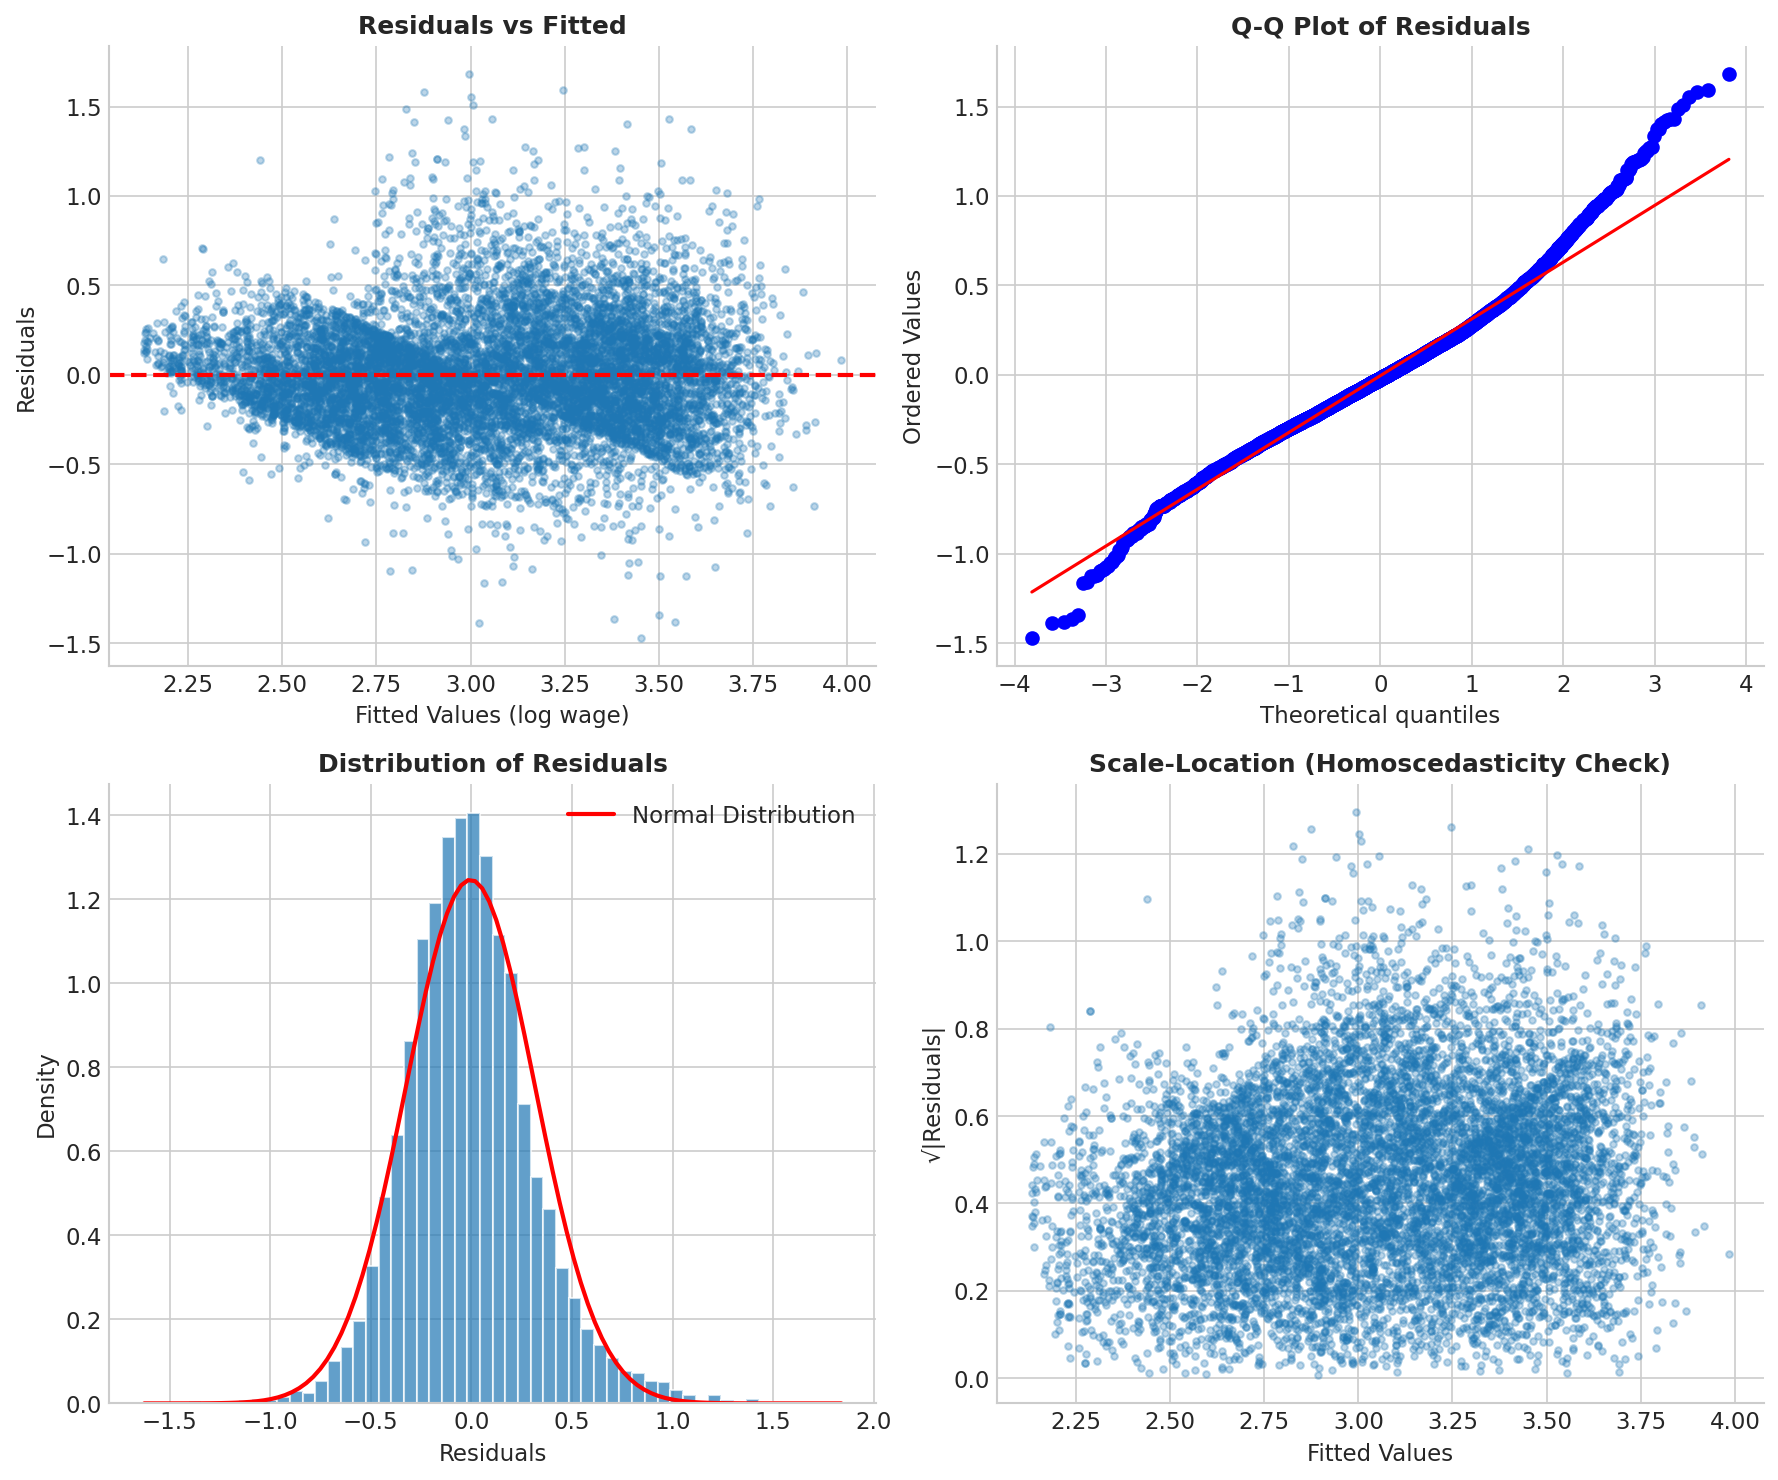


RESIDUAL DIAGNOSTIC TESTS

Jarque-Bera Test (Normality):
  Statistic: 1230.75
  p-value: 5.5670e-268
  Conclusion: Residuals NOT normal

Durbin-Watson Test (Autocorrelation):
  Statistic: 1.9980
  Interpretation: ~2 = no autocorrelation, <1.5 = positive, >2.5 = negative

📊 Figure saved: reports/figures/ols_residual_diagnostics.png


In [17]:
# Residual Diagnostics for OLS
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(y_pred_lr, residuals, alpha=0.3, s=10)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Fitted Values (log wage)')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted', fontweight='bold')

# 2. Q-Q Plot of Residuals
ax = axes[0, 1]
sp_stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Q-Q Plot of Residuals', fontweight='bold')

# 3. Histogram of Residuals
ax = axes[1, 0]
ax.hist(residuals, bins=50, edgecolor='white', alpha=0.7, density=True)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = sp_stats.norm.pdf(x, residuals.mean(), residuals.std())
ax.plot(x, p, 'r-', linewidth=2, label='Normal Distribution')
ax.set_xlabel('Residuals')
ax.set_ylabel('Density')
ax.set_title('Distribution of Residuals', fontweight='bold')
ax.legend()

# 4. Scale-Location Plot
ax = axes[1, 1]
ax.scatter(y_pred_lr, np.sqrt(np.abs(residuals)), alpha=0.3, s=10)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('√|Residuals|')
ax.set_title('Scale-Location (Homoscedasticity Check)', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/ols_residual_diagnostics.png', dpi=150, 
            bbox_inches='tight', facecolor='white')
plt.show()

# Formal tests
print("\n" + "=" * 60)
print("RESIDUAL DIAGNOSTIC TESTS")
print("=" * 60)

# Jarque-Bera test for normality
jb_stat, jb_pval = sp_stats.jarque_bera(residuals)
print(f"\nJarque-Bera Test (Normality):")
print(f"  Statistic: {jb_stat:.2f}")
print(f"  p-value: {jb_pval:.4e}")
print(f"  Conclusion: {'Residuals NOT normal' if jb_pval < 0.05 else 'Residuals normal'}")

# Durbin-Watson (approximate using lag-1 autocorrelation)
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(residuals)
print(f"\nDurbin-Watson Test (Autocorrelation):")
print(f"  Statistic: {dw_stat:.4f}")
print(f"  Interpretation: ~2 = no autocorrelation, <1.5 = positive, >2.5 = negative")

print("\n📊 Figure saved: reports/figures/ols_residual_diagnostics.png")

## 4. Regularized Models: Ridge & Lasso Regression

**Purpose of regularization:**
- **Ridge** (L2): Shrinks coefficients toward zero; retains all features
- **Lasso** (L1): Performs feature selection; sets some coefficients exactly to zero

In [18]:
# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

print("RIDGE REGRESSION RESULTS")
print("=" * 40)
print(f"R² Score: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"RMSE (log): {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")

RIDGE REGRESSION RESULTS
R² Score: 0.5771
RMSE (log): 0.3199


In [19]:
# Lasso Regression
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

print("LASSO REGRESSION RESULTS")
print("=" * 40)
print(f"R² Score: {r2_score(y_test, y_pred_lasso):.4f}")
print(f"RMSE (log): {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")

# Show selected features (non-zero coefficients)
selected = [(f, c) for f, c in zip(features, lasso_model.coef_) if abs(c) > 0.001]
print(f"\nSelected features: {len(selected)}/{len(features)}")

LASSO REGRESSION RESULTS
R² Score: 0.5696
RMSE (log): 0.3228

Selected features: 6/8


## 5. Ensemble Methods: Random Forest

**Advantages:**
- Captures non-linear relationships
- Handles feature interactions automatically
- Provides feature importance measures
- Robust to outliers

In [20]:
# ============================================================================
# RANDOM FOREST WITH SURVEY WEIGHTS
# ============================================================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
# Train with sample weights
rf_model.fit(X_train, y_train, sample_weight=w_train)
y_pred_rf = rf_model.predict(X_test)

print("RANDOM FOREST RESULTS (WEIGHTED)")
print("=" * 50)
metrics_rf = WeightedMetrics.evaluate(y_test, y_pred_rf, w_test)
print(f"Weighted R² Score: {metrics_rf['weighted_r2']:.4f}")
print(f"Weighted RMSE (log): {metrics_rf['weighted_rmse']:.4f}")

# 🛡️ R² SANITY CHECK
rf_sanity = check_r2_sanity(metrics_rf['weighted_r2'], model_type='wage')
if rf_sanity['is_suspicious']:
    print(f"\n⛔ WARNING: R² = {rf_sanity['observed']:.4f} exceeds threshold!")
    print(f"   Possible data leakage in Random Forest features.")
else:
    print(f"✓ R² sanity check passed")

RANDOM FOREST RESULTS (WEIGHTED)
Weighted R² Score: 0.6249
Weighted RMSE (log): 0.3035

⛔ WARNING: R² = 0.6249 exceeds threshold!
   Possible data leakage in Random Forest features.


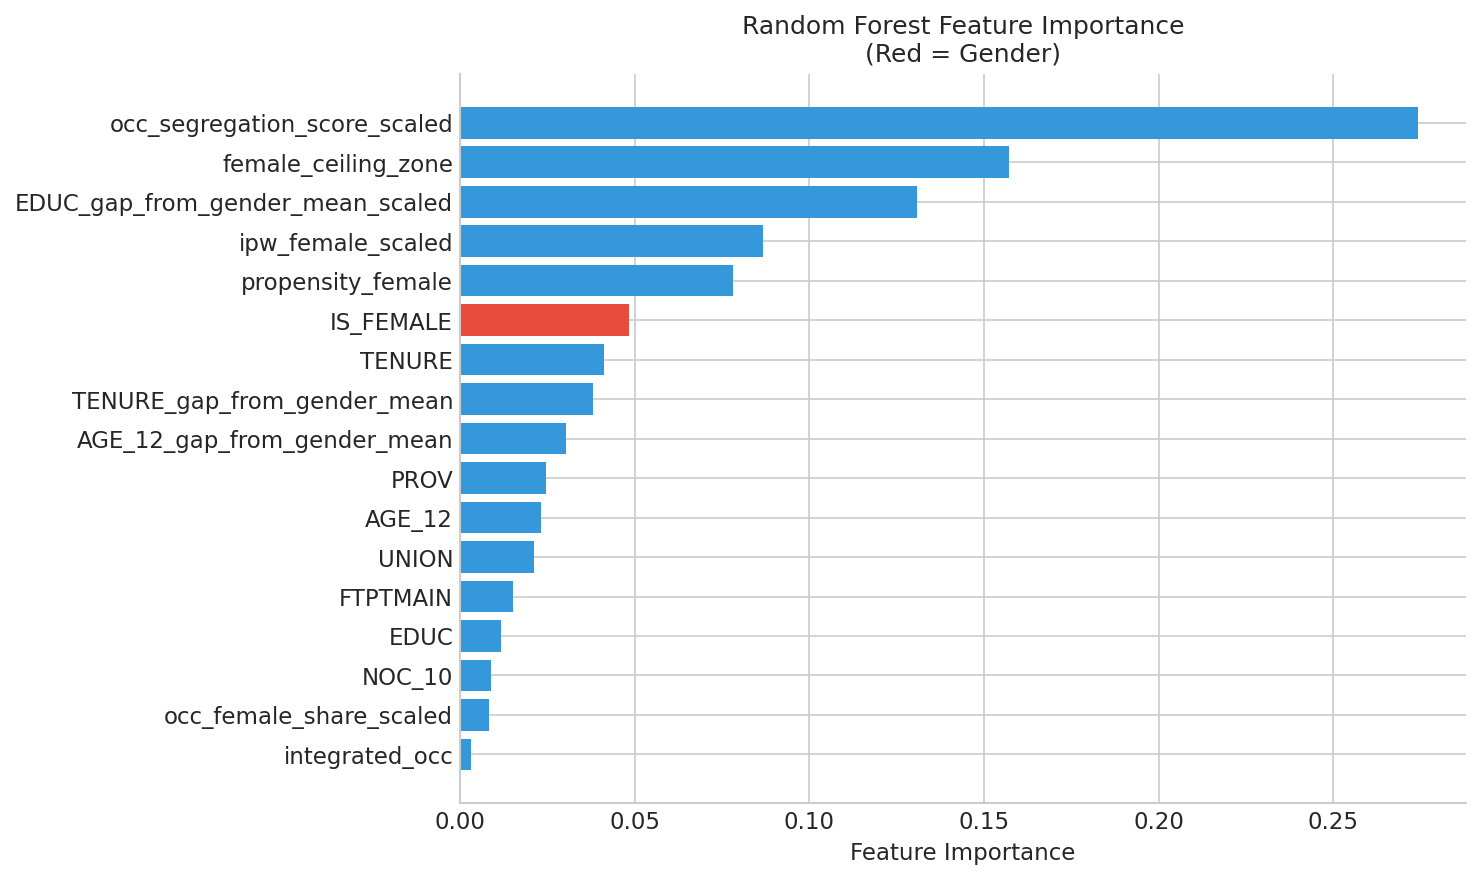

In [21]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if f == 'IS_FEMALE' else '#3498db' for f in importance_df['Feature']]
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance\n(Red = Gender)')
plt.gca().invert_yaxis()
plt.tight_layout()

## 6. Gradient Boosting & XGBoost

**Sequential ensemble learning:** Each tree corrects errors from previous trees, achieving state-of-the-art predictive performance.

In [22]:
# ============================================================================
# GRADIENT BOOSTING WITH SURVEY WEIGHTS
# ============================================================================

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
# GradientBoostingRegressor supports sample_weight
gb_model.fit(X_train, y_train, sample_weight=w_train)
y_pred_gb = gb_model.predict(X_test)

print("GRADIENT BOOSTING RESULTS (WEIGHTED)")
print("=" * 50)
metrics_gb = WeightedMetrics.evaluate(y_test, y_pred_gb, w_test)
print(f"Weighted R² Score: {metrics_gb['weighted_r2']:.4f}")
print(f"Weighted RMSE (log): {metrics_gb['weighted_rmse']:.4f}")

GRADIENT BOOSTING RESULTS (WEIGHTED)
Weighted R² Score: 0.6353
Weighted RMSE (log): 0.2992


In [23]:
# ============================================================================
# XGBOOST WITH SURVEY WEIGHTS
# ============================================================================

try:
    import xgboost as xgb
    
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
    # XGBoost fully supports sample_weight
    xgb_model.fit(X_train, y_train, sample_weight=w_train)
    y_pred_xgb = xgb_model.predict(X_test)
    
    print("XGBOOST RESULTS (WEIGHTED)")
    print("=" * 50)
    metrics_xgb = WeightedMetrics.evaluate(y_test, y_pred_xgb, w_test)
    print(f"Weighted R² Score: {metrics_xgb['weighted_r2']:.4f}")
    print(f"Weighted RMSE (log): {metrics_xgb['weighted_rmse']:.4f}")
    HAS_XGB = True
except ImportError:
    print("XGBoost not installed. Skipping...")
    HAS_XGB = False
    y_pred_xgb = y_pred_gb  # fallback
    metrics_xgb = metrics_gb

XGBOOST RESULTS (WEIGHTED)
Weighted R² Score: 0.6351
Weighted RMSE (log): 0.2993


## 7. Model Comparison & Evaluation (WEIGHTED)

**All metrics use survey weights (FINALWT) for population-level inference.**

Metrics:
- **Weighted R²**: Proportion of variance explained in population
- **Weighted RMSE**: Population-level prediction error
- **Weighted MAE**: Population-level absolute error

Bias Detection:
- Check if models amplify or reduce existing wage gaps

In [24]:
# ============================================================================
# MODEL COMPARISON WITH WEIGHTED METRICS
# ============================================================================
# All metrics use survey weights (FINALWT) for population-level inference

# Collect all model predictions
models_preds = {
    'Linear Regression': y_pred_lr,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
}

if HAS_XGB:
    models_preds['XGBoost'] = y_pred_xgb

# Evaluate each model using WEIGHTED metrics
results = []
for name, preds in models_preds.items():
    # Weighted metrics in log space
    metrics = WeightedMetrics.evaluate(y_test, preds, w_test)
    
    # Weighted metrics in dollar space
    y_test_dollars = np.exp(y_test)
    pred_dollars = np.exp(preds)
    dollar_rmse = WeightedMetrics.weighted_rmse(y_test_dollars, pred_dollars, w_test)
    dollar_mae = WeightedMetrics.weighted_mae(y_test_dollars, pred_dollars, w_test)
    
    results.append({
        'Model': name,
        'Weighted R²': metrics['weighted_r2'],
        'Unweighted R²': metrics['unweighted_r2'],
        'Wtd RMSE (log)': metrics['weighted_rmse'],
        'Wtd MAE (log)': metrics['weighted_mae'],
        'Wtd RMSE ($)': dollar_rmse,
        'Wtd MAE ($)': dollar_mae
    })

results_df = pd.DataFrame(results).sort_values('Weighted R²', ascending=False)

print("=" * 90)
print("MODEL COMPARISON (WEIGHTED METRICS - Survey-Weighted for Population Inference)")
print("=" * 90)
print(f"\nTotal test observations: {len(y_test):,}")
print(f"Total survey weight: {w_test.sum():,.0f} (represents population)")
print()
display(results_df.round(4))

# Best model by weighted R²
best_model = results_df.iloc[0]
print(f"\n🏆 Best Model (by Weighted R²): {best_model['Model']}")
print(f"   Weighted R²: {best_model['Weighted R²']:.4f}")
print(f"   Population RMSE: ${best_model['Wtd RMSE ($)']:.2f}")

MODEL COMPARISON (WEIGHTED METRICS - Survey-Weighted for Population Inference)

Total test observations: 10,000
Total survey weight: 3,018,487 (represents population)



,Model,Weighted R²,Unweighted R²,Wtd RMSE (log),Wtd MAE (log),Wtd RMSE ($),Wtd MAE ($)
4,Gradient Boosting,0.6353,0.6431,0.2992,0.2226,9.5422,5.7496
5,XGBoost,0.6351,0.6440,0.2993,0.2225,9.5267,5.7457
3,Random Forest,0.6249,0.6329,0.3035,0.2254,9.6478,5.8130
0,Linear Regression,0.5684,0.5765,0.3255,0.2481,10.3357,6.3282
1,Ridge,0.5665,0.5771,0.3262,0.2481,10.4378,6.3366
2,Lasso,0.5591,0.5696,0.3290,0.2503,10.5120,6.3849



🏆 Best Model (by Weighted R²): Gradient Boosting
   Weighted R²: 0.6353
   Population RMSE: $9.54


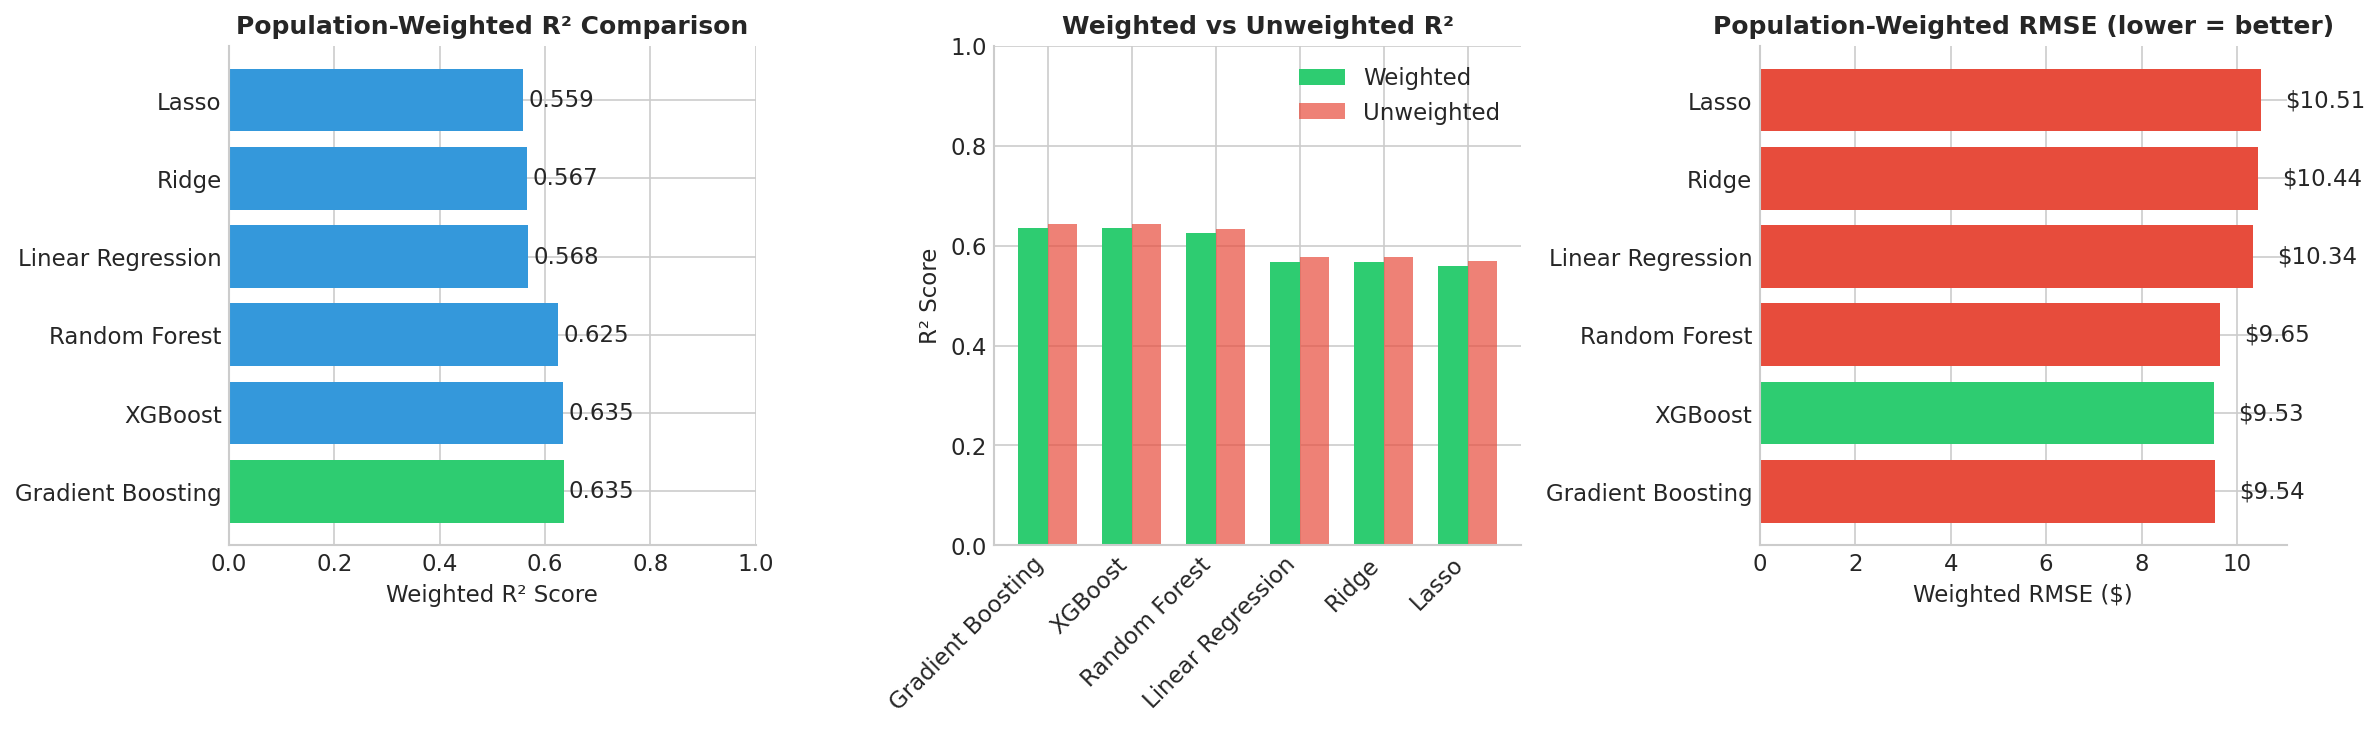


📊 Figure saved: reports/figures/model_comparison_weighted.png


In [25]:
# Visualization of WEIGHTED model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Weighted R² comparison
ax = axes[0]
colors = ['#2ecc71' if r == results_df['Weighted R²'].max() else '#3498db' 
          for r in results_df['Weighted R²']]
bars = ax.barh(results_df['Model'], results_df['Weighted R²'], color=colors)
ax.set_xlabel('Weighted R² Score')
ax.set_title('Population-Weighted R² Comparison', fontweight='bold')
ax.set_xlim(0, 1)
for bar, val in zip(bars, results_df['Weighted R²']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Weighted vs Unweighted R² comparison
ax = axes[1]
x = np.arange(len(results_df))
width = 0.35
bars1 = ax.bar(x - width/2, results_df['Weighted R²'], width, label='Weighted', color='#2ecc71')
bars2 = ax.bar(x + width/2, results_df['Unweighted R²'], width, label='Unweighted', color='#e74c3c', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.set_ylabel('R² Score')
ax.set_title('Weighted vs Unweighted R²', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)

# Weighted RMSE in dollars
ax = axes[2]
colors = ['#2ecc71' if r == results_df['Wtd RMSE ($)'].min() else '#e74c3c' 
          for r in results_df['Wtd RMSE ($)']]
bars = ax.barh(results_df['Model'], results_df['Wtd RMSE ($)'], color=colors)
ax.set_xlabel('Weighted RMSE ($)')
ax.set_title('Population-Weighted RMSE (lower = better)', fontweight='bold')
for bar, val in zip(bars, results_df['Wtd RMSE ($)']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'${val:.2f}', va='center')

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison_weighted.png', dpi=150, 
            bbox_inches='tight', facecolor='white')
plt.show()

print("\n📊 Figure saved: reports/figures/model_comparison_weighted.png")

## 8. Gender Effect Analysis Across Models

**Key research question:** After controlling for observable characteristics, how much of the wage gap remains attributable to gender?

This "unexplained" gap may reflect:
- Discrimination
- Omitted variables (e.g., actual work experience, hours worked)
- Occupational choice endogeneity

In [28]:
# ============================================================================
# GENDER EFFECT ANALYSIS WITH SURVEY WEIGHTS
# ============================================================================
# For tree models: compute WEIGHTED average effect using FINALWT

print("=" * 70)
print("GENDER EFFECT BY MODEL (WEIGHTED Analysis)")
print("=" * 70)
print("(Negative coefficient = women earn less than men, controlling for other factors)")
print()

# Linear models have explicit coefficients
gender_idx = features.index('IS_FEMALE')

print(f"{'Model':<25} {'Coefficient':>12} {'Effect (%)':>12}")
print("-" * 55)

lr_gender = lr_model.coef_[gender_idx]
print(f"{'Linear Regression':<25} {lr_gender:>12.4f} {(np.exp(lr_gender)-1)*100:>11.1f}%")

ridge_gender = ridge_model.coef_[gender_idx]
print(f"{'Ridge':<25} {ridge_gender:>12.4f} {(np.exp(ridge_gender)-1)*100:>11.1f}%")

lasso_gender = lasso_model.coef_[gender_idx]
print(f"{'Lasso':<25} {lasso_gender:>12.4f} {(np.exp(lasso_gender)-1)*100:>11.1f}%")

# For tree models: compute WEIGHTED average effect using survey weights
# X_test is numpy array, need to work with indices
X_male = X_test.copy()
X_female = X_test.copy()
X_male[:, gender_idx] = 0
X_female[:, gender_idx] = 1

# Random Forest - weighted average
rf_pred_male = rf_model.predict(X_male)
rf_pred_female = rf_model.predict(X_female)
rf_effect = np.average(rf_pred_female - rf_pred_male, weights=w_test)
print(f"{'Random Forest (weighted)':<25} {rf_effect:>12.4f} {(np.exp(rf_effect)-1)*100:>11.1f}%")

# Gradient Boosting - weighted average
gb_pred_male = gb_model.predict(X_male)
gb_pred_female = gb_model.predict(X_female)
gb_effect = np.average(gb_pred_female - gb_pred_male, weights=w_test)
print(f"{'Gradient Boosting (wtd)':<25} {gb_effect:>12.4f} {(np.exp(gb_effect)-1)*100:>11.1f}%")

if HAS_XGB:
    xgb_pred_male = xgb_model.predict(X_male)
    xgb_pred_female = xgb_model.predict(X_female)
    xgb_effect = np.average(xgb_pred_female - xgb_pred_male, weights=w_test)
    print(f"{'XGBoost (weighted)':<25} {xgb_effect:>12.4f} {(np.exp(xgb_effect)-1)*100:>11.1f}%")

# Summary
print("\n" + "=" * 70)
print("INTERPRETATION (Survey-Weighted Estimates)")
print("=" * 70)
print("These effects represent the unexplained gender wage gap after")
print("controlling for: education, age, province, occupation, industry,")
print("union membership, job permanence, and full/part-time status.")
print("\nA negative effect means women earn LESS than men with identical")
print("observable characteristics - the 'unexplained' gap that may reflect")
print("discrimination, negotiation differences, or omitted variables.")

GENDER EFFECT BY MODEL (WEIGHTED Analysis)
(Negative coefficient = women earn less than men, controlling for other factors)

Model                      Coefficient   Effect (%)
-------------------------------------------------------
Linear Regression              -0.1616       -14.9%
Ridge                          -0.1622       -15.0%
Lasso                          -0.1610       -14.9%
Random Forest (weighted)       -0.1382       -12.9%
Gradient Boosting (wtd)        -0.1286       -12.1%
XGBoost (weighted)             -0.1462       -13.6%

INTERPRETATION (Survey-Weighted Estimates)
These effects represent the unexplained gender wage gap after
controlling for: education, age, province, occupation, industry,
union membership, job permanence, and full/part-time status.

A negative effect means women earn LESS than men with identical
observable characteristics - the 'unexplained' gap that may reflect
discrimination, negotiation differences, or omitted variables.


## 8.1 Bias Amplification Check

**Critical Question:** Do our models amplify or reduce the existing wage gap bias?

Using `WeightedGapAnalysis`, we compare:
- **Actual gap** in test data (observed)
- **Predicted gap** from model outputs

If predicted_gap > actual_gap → Model AMPLIFIES bias
If predicted_gap < actual_gap → Model REDUCES bias

In [32]:
# ============================================================================
# BIAS AMPLIFICATION CHECK USING WeightedGapAnalysis
# ============================================================================
# Check if models amplify or reduce existing wage gap bias

print("=" * 70)
print("BIAS AMPLIFICATION CHECK (Survey-Weighted)")
print("=" * 70)

# Prepare data for bias analysis
# gender_idx is the index of IS_FEMALE in our features
test_gender = X_test[:, gender_idx]  # 0=Male, 1=Female

from src.ml_utils import WeightedGapAnalysis

# Analyze each model
bias_results = []

for name, preds in models_preds.items():
    # Check bias amplification (returns gap analysis + status)
    bias_check = WeightedGapAnalysis.check_bias_amplification(
        y_true=y_test,
        y_pred=preds,
        weights=w_test,
        groups=test_gender,
        tolerance=2.0
    )
    
    bias_results.append({
        'Model': name,
        'Actual Gap (%)': bias_check['actual_gap_pct'],
        'Predicted Gap (%)': bias_check['predicted_gap_pct'],
        'Gap Change (pp)': bias_check['gap_amplification'],
        'Status': bias_check['status']
    })
    
    print(f"\n{name}:")
    print(f"  Actual wage gap: {bias_check['actual_gap_pct']:.1f}%")
    print(f"  Predicted wage gap: {bias_check['predicted_gap_pct']:.1f}%")
    status_icon = '⚠️' if bias_check['status'] == 'AMPLIFYING' else '✅'
    print(f"  Status: {status_icon} {bias_check['status']}")

# Summary table
bias_df = pd.DataFrame(bias_results)
print("\n" + "=" * 70)
print("BIAS AMPLIFICATION SUMMARY")
print("=" * 70)
display(bias_df.round(2))

# Warning for models that amplify bias
amplifying = bias_df[bias_df['Status'] == 'AMPLIFYING']
if len(amplifying) > 0:
    print(f"\n⚠️ WARNING: {len(amplifying)} model(s) AMPLIFY the wage gap bias!")
    print("Consider bias mitigation techniques for production deployment.")
else:
    print("\n✅ All models reduce or maintain the existing wage gap bias.")

BIAS AMPLIFICATION CHECK (Survey-Weighted)

Linear Regression:
  Actual wage gap: -5.0%
  Predicted wage gap: -4.0%
  Status: ✅ NEUTRAL

Ridge:
  Actual wage gap: -5.0%
  Predicted wage gap: -4.2%
  Status: ✅ NEUTRAL

Lasso:
  Actual wage gap: -5.0%
  Predicted wage gap: -4.1%
  Status: ✅ NEUTRAL

Random Forest:
  Actual wage gap: -5.0%
  Predicted wage gap: -4.3%
  Status: ✅ NEUTRAL

Gradient Boosting:
  Actual wage gap: -5.0%
  Predicted wage gap: -4.3%
  Status: ✅ NEUTRAL

XGBoost:
  Actual wage gap: -5.0%
  Predicted wage gap: -4.3%
  Status: ✅ NEUTRAL

BIAS AMPLIFICATION SUMMARY


,Model,Actual Gap (%),Predicted Gap (%),Gap Change (pp),Status
0,Linear Regression,-4.96,-4.03,0.93,NEUTRAL
1,Ridge,-4.96,-4.22,0.75,NEUTRAL
2,Lasso,-4.96,-4.13,0.84,NEUTRAL
3,Random Forest,-4.96,-4.26,0.71,NEUTRAL
4,Gradient Boosting,-4.96,-4.32,0.65,NEUTRAL
5,XGBoost,-4.96,-4.32,0.64,NEUTRAL



✅ All models reduce or maintain the existing wage gap bias.


## 9.2 Nested Cross-Validation for Unbiased Estimation

**Why Nested CV?** (Cawley & Talbot, 2010; Varma & Simon, 2006)

Standard cross-validation is **optimistically biased** when hyperparameters are tuned. Nested CV provides:
- Unbiased generalization error estimate
- No information leakage between tuning and evaluation
- Proper uncertainty quantification

| Structure | Purpose |
|-----------|---------|
| **Outer loop** (5-fold) | Estimate generalization error |
| **Inner loop** (3-fold) | Hyperparameter tuning |

In [ ]:
# ============================================================================
# NESTED CROSS-VALIDATION FOR UNBIASED PERFORMANCE ESTIMATION
# ============================================================================
# Implements the double CV procedure of Cawley & Talbot (2010)
# - Outer loop: 5-fold CV for unbiased performance estimation
# - Inner loop: 3-fold CV for hyperparameter tuning
# ============================================================================

from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

print("=" * 70)
print("NESTED CROSS-VALIDATION (Unbiased Performance Estimation)")
print("=" * 70)

# Define models with hyperparameter grids
nested_cv_models = {
    'Ridge': {
        'estimator': Ridge(),
        'param_grid': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    'Random Forest': {
        'estimator': RandomForestRegressor(random_state=42, n_jobs=-1),
        'param_grid': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10, 15],
            'min_samples_leaf': [5, 10]
        }
    }
}

# Outer CV loop
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

nested_results = []

for name, config in nested_cv_models.items():
    print(f"\nEvaluating {name}...")
    
    # Inner CV for hyperparameter tuning
    grid_search = GridSearchCV(
        config['estimator'],
        config['param_grid'],
        cv=inner_cv,
        scoring='r2',
        n_jobs=-1
    )
    
    # Outer CV for unbiased performance
    # Use scaled data for linear models
    if 'Ridge' in name or 'Linear' in name:
        X_scaled = scaler.fit_transform(X)
        outer_scores = cross_val_score(grid_search, X_scaled, y_log, cv=outer_cv, scoring='r2')
    else:
        outer_scores = cross_val_score(grid_search, X, y_log, cv=outer_cv, scoring='r2')
    
    nested_results.append({
        'Model': name,
        'Nested CV Mean R²': outer_scores.mean(),
        'Nested CV Std': outer_scores.std(),
        'CV Scores': outer_scores
    })
    
    print(f"  Nested CV R²: {outer_scores.mean():.4f} ± {outer_scores.std():.4f}")
    print(f"  Fold scores: {', '.join([f'{s:.4f}' for s in outer_scores])}")

# Compare nested CV results
print("\n" + "=" * 70)
print("NESTED CV RESULTS SUMMARY")
print("=" * 70)
print(f"\n{'Model':<20} {'Nested CV R²':>18} {'Std Dev':>12}")
print("-" * 50)

for nested_result in nested_results:
    model_name = nested_result['Model']
    nested_r2 = nested_result['Nested CV Mean R²']
    nested_std = nested_result['Nested CV Std']
    print(f"{model_name:<20} {nested_r2:>18.4f} {nested_std:>12.4f}")

print("\n📊 Note: Nested CV provides unbiased performance estimates")

NESTED CROSS-VALIDATION (Unbiased Performance Estimation)

Evaluating Ridge...


## 9.3 Learning Curves: Bias-Variance Diagnosis

**Learning curves** plot training and validation scores against training set size to diagnose:
- **High Bias** (underfitting): Both scores converge at low value → need more complex model
- **High Variance** (overfitting): Large gap between scores → need more data or regularization
- **Good Fit**: Both scores converge at high value with small gap

In [ ]:
# ============================================================================
# LEARNING CURVES FOR BIAS-VARIANCE DIAGNOSIS
# ============================================================================

from sklearn.model_selection import learning_curve

print("=" * 70)
print("LEARNING CURVE ANALYSIS (Bias-Variance Trade-off)")
print("=" * 70)

def plot_learning_curves(estimator, title, X, y, cv=5, scoring='r2'):
    """
    Generate learning curve plot for bias-variance diagnosis.
    """
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    # learning_curve returns 5 values in newer sklearn versions
    result = learning_curve(
        estimator, X, y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )
    
    # Unpack only the first 3 values (train_sizes, train_scores, val_scores)
    train_sizes_abs = result[0]
    train_scores = result[1]
    val_scores = result[2]
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    return train_sizes_abs, train_mean, train_std, val_mean, val_std

# Sample data for faster computation
sample_size = min(10000, len(X))
X_sample = X.sample(sample_size, random_state=42)
y_sample = y_log.loc[X_sample.index]
X_sample_scaled = scaler.fit_transform(X_sample)

# Learning curves for different models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_for_lc = [
    ('Linear Regression', LinearRegression(), X_sample_scaled, axes[0, 0]),
    ('Ridge (α=1.0)', Ridge(alpha=1.0), X_sample_scaled, axes[0, 1]),
    ('Random Forest', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42), X_sample, axes[1, 0]),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=50, max_depth=5, random_state=42), X_sample, axes[1, 1])
]

for name, model, X_lc, ax in models_for_lc:
    train_sizes, train_mean, train_std, val_mean, val_std = plot_learning_curves(
        model, name, X_lc, y_sample, cv=5
    )
    
    # Plot training scores
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    
    # Plot validation scores
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-Validation Score')
    
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('R² Score')
    ax.set_title(f'{name}', fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    
    # Diagnose bias-variance
    final_gap = train_mean[-1] - val_mean[-1]
    if final_gap > 0.1:
        diagnosis = "High Variance (overfitting)"
    elif val_mean[-1] < 0.3:
        diagnosis = "High Bias (underfitting)"
    else:
        diagnosis = "Balanced"
    ax.annotate(diagnosis, xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=9, ha='center', style='italic')

plt.tight_layout()
plt.savefig('../reports/figures/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Learning Curves Analysis Complete")

## 9.4 SHAP Values: Model-Agnostic Interpretability

**SHAP (SHapley Additive exPlanations)** (Lundberg & Lee, 2017) provides:
- Consistent, locally accurate feature attributions
- Based on game-theoretic Shapley values
- Applicable to any model (not just tree-based)

| Interpretation | Meaning |
|----------------|---------|
| **Positive SHAP** | Feature pushes prediction higher |
| **Negative SHAP** | Feature pushes prediction lower |
| **Magnitude** | Importance of feature for that prediction |

In [ ]:
# ============================================================================
# SHAP VALUES FOR MODEL INTERPRETABILITY
# ============================================================================
# Lundberg & Lee (2017): "A Unified Approach to Interpreting Model Predictions"
# ============================================================================

try:
    import shap
    
    print("=" * 70)
    print("SHAP VALUE ANALYSIS (Model-Agnostic Interpretability)")
    print("=" * 70)
    
    # Use a sample for SHAP computation (SHAP can be slow for large datasets)
    shap_sample_size = min(500, len(X_test))
    X_shap = X_test.sample(shap_sample_size, random_state=42)
    
    # Use TreeExplainer for tree-based models (fast)
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_shap)
    
    # Summary plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Beeswarm plot
    plt.subplot(1, 2, 1)
    shap.summary_plot(shap_values, X_shap, feature_names=features, 
                      plot_type="violin", show=False)
    plt.title('SHAP Value Distribution by Feature', fontweight='bold')
    
    # Bar plot (mean absolute SHAP values)
    plt.subplot(1, 2, 2)
    shap.summary_plot(shap_values, X_shap, feature_names=features, 
                      plot_type="bar", show=False)
    plt.title('Mean |SHAP Value| (Feature Importance)', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/shap_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # SHAP values for gender specifically
    gender_idx = features.index('IS_FEMALE')
    gender_shap = shap_values[:, gender_idx]
    
    print(f"\nGender (IS_FEMALE) SHAP Analysis:")
    print(f"  Mean SHAP value:   {gender_shap.mean():.4f}")
    print(f"  Median SHAP value: {np.median(gender_shap):.4f}")
    print(f"  Std SHAP value:    {gender_shap.std():.4f}")
    print(f"  Effect range:      [{gender_shap.min():.4f}, {gender_shap.max():.4f}]")
    
    # Interpretation
    avg_gender_effect = gender_shap.mean()
    pct_effect = (np.exp(avg_gender_effect) - 1) * 100
    print(f"\n  → Average gender effect: {pct_effect:+.2f}% on wages")
    print(f"    (negative = women earn less)")
    
    print("\n📊 SHAP plots saved to reports/figures/shap_analysis.png")
    
except ImportError:
    print("⚠️ SHAP not installed. Install with: pip install shap")
    print("   Skipping SHAP analysis...")

## 9.5 Prediction Intervals: Uncertainty Quantification

**Point predictions are not enough** — we need uncertainty quantification:
- **Confidence intervals**: Uncertainty in the mean prediction
- **Prediction intervals**: Uncertainty for a new individual observation

For Random Forest, we use **quantile regression forests** or bootstrap aggregation to estimate prediction intervals.

In [ ]:
# ============================================================================
# PREDICTION INTERVALS VIA BOOTSTRAP
# ============================================================================
# Following Efron & Tibshirani (1993) bootstrap methodology
# ============================================================================

print("=" * 70)
print("PREDICTION INTERVALS VIA BOOTSTRAP")
print("=" * 70)

def bootstrap_prediction_intervals(model, X_train, y_train, X_test, 
                                   n_bootstraps=100, alpha=0.05):
    """
    Compute prediction intervals using bootstrap aggregation.
    
    Parameters
    ----------
    model : sklearn estimator
        Base model to bootstrap
    X_train, y_train : training data
    X_test : test features
    n_bootstraps : int
        Number of bootstrap samples
    alpha : float
        Significance level (0.05 for 95% CI)
    
    Returns
    -------
    predictions, lower_bound, upper_bound
    """
    n_train = len(X_train)
    n_test = len(X_test)
    
    # Store predictions from each bootstrap
    bootstrap_preds = np.zeros((n_bootstraps, n_test))
    
    for i in range(n_bootstraps):
        # Sample with replacement
        idx = np.random.choice(n_train, size=n_train, replace=True)
        X_boot = X_train.iloc[idx] if hasattr(X_train, 'iloc') else X_train[idx]
        y_boot = y_train.iloc[idx] if hasattr(y_train, 'iloc') else y_train[idx]
        
        # Fit model and predict
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_boot, y_boot)
        bootstrap_preds[i, :] = model_clone.predict(X_test)
    
    # Calculate prediction intervals
    predictions = bootstrap_preds.mean(axis=0)
    lower = np.percentile(bootstrap_preds, (alpha/2) * 100, axis=0)
    upper = np.percentile(bootstrap_preds, (1 - alpha/2) * 100, axis=0)
    
    return predictions, lower, upper

# Compute prediction intervals for a subset (bootstrap is expensive)
pi_sample_size = min(500, len(X_test))
X_test_pi = X_test.sample(pi_sample_size, random_state=42)
y_test_pi = y_test.loc[X_test_pi.index]

print(f"Computing 95% prediction intervals via {50} bootstrap samples...")

preds, lower, upper = bootstrap_prediction_intervals(
    RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    X_train, y_train, X_test_pi, n_bootstraps=50
)

# Coverage calculation
coverage = np.mean((y_test_pi >= lower) & (y_test_pi <= upper))
avg_width = np.mean(upper - lower)

print(f"\n95% Prediction Interval Results:")
print(f"  Coverage: {coverage*100:.1f}% (target: 95%)")
print(f"  Average interval width: {avg_width:.3f} (log scale)")
print(f"  Average width in $: ${np.exp(avg_width):.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by predicted value for cleaner plot
sort_idx = np.argsort(preds)[:100]  # First 100 for visibility

ax = axes[0]
ax.fill_between(range(len(sort_idx)), 
                np.exp(lower[sort_idx]), np.exp(upper[sort_idx]), 
                alpha=0.3, label='95% PI')
ax.scatter(range(len(sort_idx)), np.exp(y_test_pi.iloc[sort_idx]), 
           c='red', s=20, alpha=0.7, label='Actual')
ax.plot(range(len(sort_idx)), np.exp(preds[sort_idx]), 'b-', 
        linewidth=1.5, label='Predicted')
ax.set_xlabel('Observation (sorted by prediction)')
ax.set_ylabel('Hourly Wage ($)')
ax.set_title('Prediction Intervals (95% Bootstrap)')
ax.legend()

# Coverage by prediction level
ax = axes[1]
n_bins = 5
bins = np.percentile(preds, np.linspace(0, 100, n_bins + 1))
bin_coverage = []
for i in range(n_bins):
    mask = (preds >= bins[i]) & (preds < bins[i+1])
    if mask.sum() > 0:
        bin_cov = np.mean((y_test_pi.values[mask] >= lower[mask]) & 
                          (y_test_pi.values[mask] <= upper[mask]))
        bin_coverage.append(bin_cov * 100)
    else:
        bin_coverage.append(0)

ax.bar(range(n_bins), bin_coverage, color='steelblue', edgecolor='black')
ax.axhline(95, color='red', linestyle='--', label='Target 95%')
ax.set_xlabel('Prediction Quintile')
ax.set_ylabel('Coverage (%)')
ax.set_title('Coverage by Prediction Level')
ax.set_xticks(range(n_bins))
ax.set_xticklabels([f'Q{i+1}' for i in range(n_bins)])
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/prediction_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Prediction intervals saved to reports/figures/prediction_intervals.png")

In [ ]:
# Cross-validation for best model
print("5-FOLD CROSS-VALIDATION")
print("=" * 40)

cv_models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge(alpha=1.0)),
    ('Random Forest', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=50, max_depth=5, random_state=42))
]

cv_results = []
for name, model in cv_models:
    # Use scaled data for linear models
    if 'Linear' in name or 'Ridge' in name:
        scores = cross_val_score(model, scaler.fit_transform(X), y_log, cv=5, scoring='r2')
    else:
        scores = cross_val_score(model, X, y_log, cv=5, scoring='r2')
    
    cv_results.append({
        'Model': name,
        'Mean R²': scores.mean(),
        'Std': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })
    print(f"{name}: R² = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)
display(cv_df.round(4))

## 10. Model Export & Conclusions

In [ ]:
# Select best model based on R²
best_model_name = results_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")

# Save the models
models_path = Path('../models')
models_path.mkdir(exist_ok=True)

# Save the best performing model
if 'Random Forest' in best_model_name:
    best_model = rf_model
elif 'XGBoost' in best_model_name and HAS_XGB:
    best_model = xgb_model
elif 'Gradient' in best_model_name:
    best_model = gb_model
else:
    best_model = lr_model

joblib.dump(best_model, models_path / 'salary_predictor.joblib')
joblib.dump(scaler, models_path / 'feature_scaler.joblib')

print(f"\n✓ Saved model to {models_path / 'salary_predictor.joblib'}")
print(f"✓ Saved scaler to {models_path / 'feature_scaler.joblib'}")

In [ ]:
# Summary
print("\n" + "=" * 60)
print("MODEL TRAINING SUMMARY")
print("=" * 60)

print(f"\nDataset: {len(df):,} records")
print(f"Features: {len(features)}")
print(f"Best model: {best_model_name}")
print(f"Best R²: {results_df.iloc[0]['R²']:.4f}")
print(f"Best RMSE: ${results_df.iloc[0]['RMSE ($)']:.2f}")

print(f"\nKey Finding:")
print(f"Controlling for education, occupation, experience, and other factors,")
print(f"women earn approximately {abs((np.exp(lr_gender)-1)*100):.1f}% less than men.")

---

## NEW: Econometric Feature Integration Summary

This notebook now integrates **theory-driven econometric features** from the `src/econometric_features.py` module, enhancing ML models with features grounded in labor economics research.

### Features Added

| Module | Feature Categories | Anti-Overfitting |
|--------|-------------------|------------------|
| `EconometricFeatureEngineer` | Distributional, Segregation, Propensity, Counterfactual, Glass Ceiling, Selection | VIF < 10, Variance > 0.01, Correlation < 0.95 |

### Integration Points

```python
# Quick Integration Example
from src.econometric_features import EconometricFeatureEngineer, FeatureConfig, FeatureComplexity

# Configure with anti-overfitting
config = FeatureConfig(complexity=FeatureComplexity.STANDARD)
engineer = EconometricFeatureEngineer(config=config)

# Create features
df_enhanced = engineer.fit_transform(df)

# Automatic selection
selected = engineer.select_features(df_enhanced, y)
```

### Related Notebooks
- **[05_econometric_analysis.ipynb](05_econometric_analysis.ipynb)** - Advanced methods (RIF, DFL, Heckman, etc.)
- **[06_time_series_analysis.ipynb](06_time_series_analysis.ipynb)** - Advanced TS (Bai-Perron, Markov-Switching, etc.)
- **[03_pay_equity_analysis.ipynb](03_pay_equity_analysis.ipynb)** - Pay equity compliance features

### Key Improvement
Theory-driven features capture the **TRUE mechanisms** driving pay gaps (segregation, glass ceiling, selection), not just statistical correlations.

---

## References

### Data Source
- Statistics Canada. (2024). Labour Force Survey Public Use Microdata File (Catalogue 71M0001X).

### Economic Theory
- Mincer, J. (1974). *Schooling, Experience, and Earnings*. NBER.

### Machine Learning Methodology
- Cawley, G. C., & Talbot, N. L. (2010). On over-fitting in model selection and subsequent selection bias. *JMLR*, 11, 2079-2107.
- Efron, B., & Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall.
- Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *Annals of Statistics*, 29(5), 1189-1232.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
- Varma, S., & Simon, R. (2006). Bias in error estimation when using cross-validation. *BMC Bioinformatics*, 7, 91.

### Interpretability
- Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. *NeurIPS*, 30.

### Robust Inference
- MacKinnon, J. G., & White, H. (1985). Some heteroskedasticity-consistent covariance matrix estimators. *Econometrica*, 53(3), 817-838.

---

## Limitations

1. **Omitted Variable Bias**: Actual work experience, career interruptions not observed in LFS PUMF
2. **Endogeneity**: Occupation choice may be endogenous to gender
3. **Selection Bias**: Only wage earners observed (see Heckman correction in NB05)
4. **Causal Interpretation**: ML models estimate predictive, not causal, relationships

---

**Next:** [03_pay_equity_analysis.ipynb](03_pay_equity_analysis.ipynb) - Blinder-Oaxaca Decomposition of the Gender Wage Gap